In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.float_format','{:.2f}'.format)

df = pd.read_csv('../data/train.csv')

df = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 
         'YearBuilt', 'Neighborhood', 'SalePrice']].dropna()

df.columns = ['Area', 'Bedrooms', 'Bathrooms', 
              'YearBuilt', 'Neighborhood', 'Price']

print("Shape:", df.shape)
df.head()

Shape: (1460, 6)


,Area,Bedrooms,Bathrooms,YearBuilt,Neighborhood,Price
0,1710,3,2,2003,CollgCr,208500
1,1262,3,2,1976,Veenker,181500
2,1786,3,2,2001,CollgCr,223500
3,1717,3,1,1915,Crawfor,140000
4,2198,4,2,2000,NoRidge,250000


In [3]:
print("Basic Statistics: ")
print(df.describe())

print("\nNeighborhood Categories: ")
print(df['Neighborhood'].value_counts())

Basic Statistics: 
         Area  Bedrooms  Bathrooms  YearBuilt     Price
count 1460.00   1460.00    1460.00    1460.00   1460.00
mean  1515.46      2.87       1.57    1971.27 180921.20
std    525.48      0.82       0.55      30.20  79442.50
min    334.00      0.00       0.00    1872.00  34900.00
25%   1129.50      2.00       1.00    1954.00 129975.00
50%   1464.00      3.00       2.00    1973.00 163000.00
75%   1776.75      3.00       2.00    2000.00 214000.00
max   5642.00      8.00       3.00    2010.00 755000.00

Neighborhood Categories: 
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64


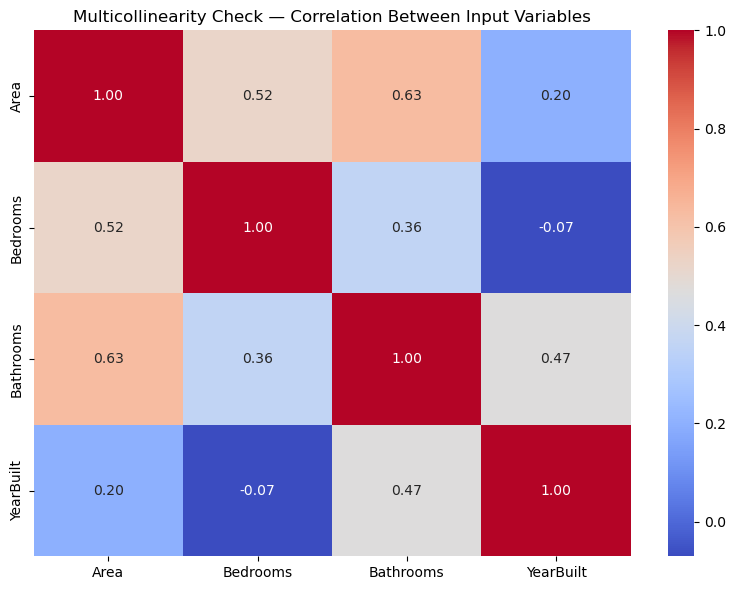

In [5]:
# Correlation between X variables — not X and Y
# We want X variables to correlate with Price but NOT with each other
numeric_cols = df[['Area', 'Bedrooms', 'Bathrooms', 'YearBuilt']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm')
plt.title('Multicollinearity Check — Correlation Between Input Variables')
plt.tight_layout()
plt.savefig('multicollinearity_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Rule: if two inputs correlate above 0.8 with each other
# consider removing one — they are telling the model the same thing

In [9]:
# Neighborhood is text — we cannot do math on text
# Convert to dummy variables (0s and 1s)
df_dummies = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True).astype(int)
# drop_first=True drops one category to avoid the dummy variable trap

print("Shape after dummies:", df_dummies.shape)
print("\nNew columns added:", 
      [col for col in df_dummies.columns if 'Neighborhood' in col][:5])

Shape after dummies: (1460, 29)

New columns added: ['Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr']


In [11]:
feature_cols = ['Area', 'Bedrooms', 'Bathrooms', 'YearBuilt'] + \
               [col for col in df_dummies.columns if 'Neighborhood' in col]

X = df_dummies[feature_cols].astype(float)
y = df_dummies['Price'].astype(float)

X_const = sm.add_constant(X)

results = sm.OLS(y, X_const).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     163.8
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:04:20   Log-Likelihood:                -17496.
No. Observations:                1460   AIC:                         3.505e+04
Df Residuals:                    1431   BIC:                         3.520e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -1.22e+06   1.49e+05     -8.173      0.000   -1.51e+06   -9.27e+05
Area                    88.9791      3.053     29.145      0.000      82.990      94.968
Bedrooms             -1.077e+04   1652.219     -6.521      0.000    -1.4e+04   -7532.882
Bathrooms            -1638.3723   2912.718     -0.562      0.574   -7352.028    4075.283
YearBuilt              653.4687     74.506      8.771      0.000     507.316     799.622
Neighborhood_Blueste -3.107e+04   2.93e+04     -1.059      0.290   -8.86e+04    2.65e+04
Neighborhood_BrDale   -3.68e+04    1.4e+04     -2.632      0.009   -6.42e+04   -9378.071
Neighborhood_BrkSide  5327.5147   1.21e+04      0.439      0.661   -1.85e+04    2.91e+04
Neighborhood_ClearCr  2.198e+04   1.25e+04      1.765      0.078   -2443.628    4.64e+04
Neighborhood_CollgCr  1.374e+04   1.02e+04      1.354      0.176   -6173.865    3.37e+04
Neighborhood_Crawfor  3.687e+04    1.2e+04      3.076      0.002    1.34e+04    6.04e+04
Neighborhood_Edwards -1.611e+04    1.1e+04     -1.464      0.143   -3.77e+04    5476.737
Neighborhood_Gilbert -2522.2229   1.06e+04     -0.237      0.812   -2.34e+04    1.83e+04
Neighborhood_IDOTRR  -1.275e+04   1.29e+04     -0.992      0.321    -3.8e+04    1.25e+04
Neighborhood_MeadowV -3.704e+04   1.38e+04     -2.688      0.007   -6.41e+04      -1e+04
Neighborhood_Mitchel -2030.7254   1.13e+04     -0.180      0.857   -2.42e+04    2.01e+04
Neighborhood_NAmes    1866.3975   1.06e+04      0.176      0.860   -1.89e+04    2.27e+04
Neighborhood_NPkVill -9716.8722   1.63e+04     -0.595      0.552   -4.17e+04    2.23e+04
Neighborhood_NWAmes   2611.0592   1.09e+04      0.239      0.811   -1.88e+04     2.4e+04
Neighborhood_NoRidge  6.919e+04   1.17e+04      5.925      0.000    4.63e+04    9.21e+04
Neighborhood_NridgHt   8.74e+04   1.06e+04      8.266      0.000    6.67e+04    1.08e+05
Neighborhood_OldTown -7661.6566   1.18e+04     -0.647      0.518   -3.09e+04    1.56e+04
Neighborhood_SWISU   -1.275e+04   1.38e+04     -0.927      0.354   -3.97e+04    1.42e+04
Neighborhood_Sawyer  -1150.8398   1.12e+04     -0.103      0.918   -2.31e+04    2.08e+04
Neighborhood_SawyerW  -563.1425    1.1e+04     -0.051      0.959   -2.21e+04    2.09e+04
Neighborhood_Somerst    2.5e+04   1.05e+04      2.392      0.017    4497.054    4.55e+04
Neighborhood_StoneBr  8.531e+04   1.24e+04      6.900      0.000    6.11e+04     1.1e+05
Neighborhood_Timber   3.872e+04   1.15e+04      3.353      0.001    1.61e+04    6.14e+04
Neighborhood_Veenker  5.192e+04   1.53e+04      3.393      0.001    2.19e+04    8.19e+04
==============================================================================
Omnibus:                      330.096   Durbin-Watson:                   1.985
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11493.63

In [12]:
print("=" * 50)
print("MODEL RESULTS SUMMARY")
print("=" * 50)

r2 = results.rsquared
adj_r2 = results.rsquared_adj
f_stat = results.fvalue
f_pvalue = results.f_pvalue

print(f"\nR-squared:          {round(r2, 4)}")
print(f"Adjusted R-squared: {round(adj_r2, 4)}")
print(f"F-statistic:        {round(f_stat, 2)}")
print(f"F-test p-value:     {round(f_pvalue, 6)}")

print("\nInterpretation:")
print(f"  The model explains {round(adj_r2*100, 1)}% of price variability")
print(f"  vs {50}% in our simple model — improvement confirmed")

print("\nKey coefficients:")
key_features = ['Area', 'Bedrooms', 'Bathrooms', 'YearBuilt']
for feature in key_features:
    coef = results.params[feature]
    pval = results.pvalues[feature]
    significant = "significant" if pval < 0.05 else "NOT significant"
    print(f"  {feature}: ${round(coef, 2)} per unit — {significant}")

MODEL RESULTS SUMMARY

R-squared:          0.7622
Adjusted R-squared: 0.7575
F-statistic:        163.78
F-test p-value:     0.0

Interpretation:
  The model explains 75.8% of price variability
  vs 50% in our simple model — improvement confirmed

Key coefficients:
  Area: $88.98 per unit — significant
  Bedrooms: $-10773.91 per unit — significant
  Bathrooms: $-1638.37 per unit — NOT significant
  YearBuilt: $653.47 per unit — significant


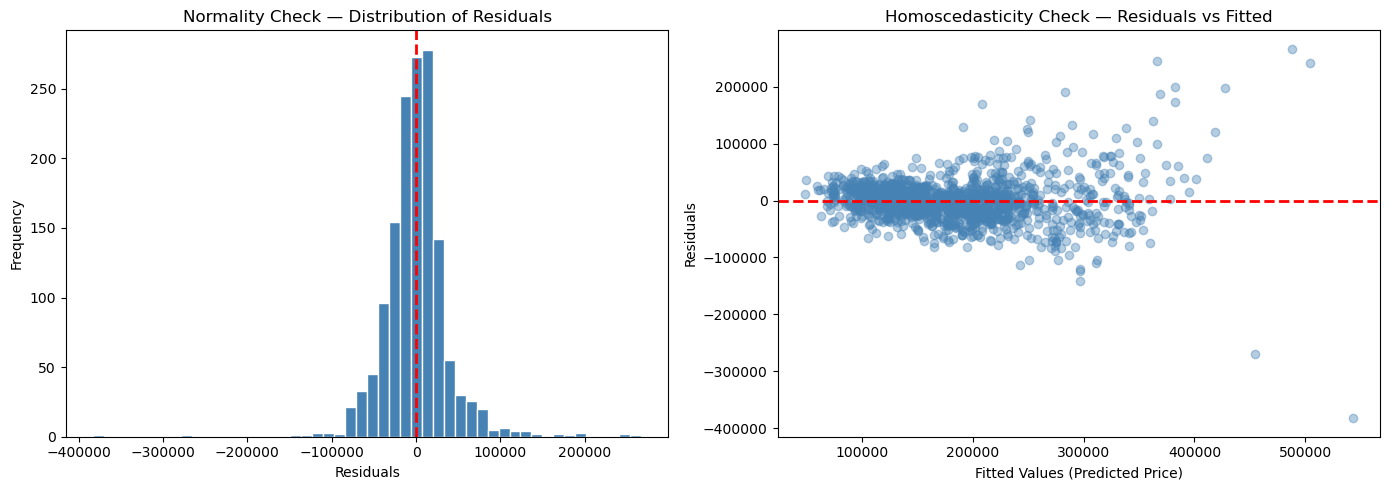

Normality: residuals should form a bell curve
Homoscedasticity: residuals should be randomly scattered around 0
No cone shape — cone means variance increases with price (violation)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get residuals
fitted_values = results.fittedvalues
residuals = results.resid

# Plot 1: Normality of residuals
axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Normality Check — Distribution of Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)

# Plot 2: Homoscedasticity — residuals vs fitted values
axes[1].scatter(fitted_values, residuals, alpha=0.4, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Homoscedasticity Check — Residuals vs Fitted')
axes[1].set_xlabel('Fitted Values (Predicted Price)')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.savefig('ols_assumptions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Normality: residuals should form a bell curve")
print("Homoscedasticity: residuals should be randomly scattered around 0")
print("No cone shape — cone means variance increases with price (violation)")

In [14]:
# VIF = Variance Inflation Factor
# Measures how much each variable is explained by other variables
# VIF below 5 = acceptable
# VIF above 10 = serious multicollinearity problem — consider removing

vif_data = pd.DataFrame()
vif_data['Feature'] = ['Area', 'Bedrooms', 'Bathrooms', 'YearBuilt']

X_vif = df[['Area', 'Bedrooms', 'Bathrooms', 'YearBuilt']]
vif_data['VIF Score'] = [variance_inflation_factor(X_vif.values, i) 
                          for i in range(X_vif.shape[1])]

print("VIF Scores — Multicollinearity Check:")
print(vif_data)
print("\nRule: VIF < 5 is safe, VIF > 10 is a problem")

VIF Scores — Multicollinearity Check:
     Feature  VIF Score
0       Area      18.47
1   Bedrooms      18.08
2  Bathrooms      15.35
3  YearBuilt      16.59

Rule: VIF < 5 is safe, VIF > 10 is a problem


In [15]:
# This is the most satisfying part — using your model on real input
# Create a new house with known features

# Build input row — must match all training columns
new_house = pd.DataFrame(columns=X_const.columns)
new_house.loc[0] = 0  # fill everything with 0 first

# Fill in the house features
new_house['const'] = 1
new_house['Area'] = 2000        # 2000 sq ft
new_house['Bedrooms'] = 3       # 3 bedrooms
new_house['Bathrooms'] = 2      # 2 bathrooms
new_house['YearBuilt'] = 2005   # built in 2005

predicted_price = results.predict(new_house)[0]

print("=" * 50)
print("HOUSE PRICE PREDICTION")
print("=" * 50)
print(f"Area:       2,000 sq ft")
print(f"Bedrooms:   3")
print(f"Bathrooms:  2")
print(f"Year Built: 2005")
print(f"\nPredicted Sale Price: ${round(predicted_price, 2):,}")

HOUSE PRICE PREDICTION
Area:       2,000 sq ft
Bedrooms:   3
Bathrooms:  2
Year Built: 2005

Predicted Sale Price: $232,750.47


In [16]:
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"Simple Linear Regression:")
print(f"  Variables:    1 (Area only)")
print(f"  R-squared:    0.50")
print(f"  Explains:     50% of price variability")

print(f"\nMultiple Linear Regression:")
print(f"  Variables:    4 + Neighborhood dummies")
print(f"  Adj R²:       {round(results.rsquared_adj, 4)}")
print(f"  Explains:     {round(results.rsquared_adj*100, 1)}% of price variability")

print(f"\nImprovement:  +{round((results.rsquared_adj - 0.50)*100, 1)}% more variability explained")
print(f"\nConclusion: Adding Bedrooms, Bathrooms, YearBuilt")
print(f"and Neighborhood significantly improves predictions.")

MODEL COMPARISON
Simple Linear Regression:
  Variables:    1 (Area only)
  R-squared:    0.50
  Explains:     50% of price variability

Multiple Linear Regression:
  Variables:    4 + Neighborhood dummies
  Adj R²:       0.7575
  Explains:     75.8% of price variability

Improvement:  +25.8% more variability explained

Conclusion: Adding Bedrooms, Bathrooms, YearBuilt
and Neighborhood significantly improves predictions.
